## Simple GA in use

1. Find nodes
2. Find neighbor nodes
3. Set parameters
    - Max routes
    - Max nodes per routes
    - Kids
    - Generations
    - Mutation?
4. Connect nodes

In [55]:
## Imports
from pathlib import Path

import zipfile
import pandas as pd

import geopandas as gpd

import networkx as nx
import matplotlib.pyplot as plt

import contextily as cx

import numpy as np
from scipy.spatial import Delaunay


In [56]:
## Load in the data
GTFS_PATH = Path("data/raw/GTFS_Copenhagen.zip")

if not GTFS_PATH.exists():
    raise FileNotFoundError(
        "GTFS ZIP not found. Download it as described in README.md"
    )

with zipfile.ZipFile(GTFS_PATH, "r") as z:
    names = z.namelist()
    print("Number of files in zip:", len(names))
   # for n in names[:24]:
            # print(" -", n)

with zipfile.ZipFile(GTFS_PATH, "r") as z:
    stops = pd.read_csv(z.open("GTFS_Copenhagen/stops.txt"))
    routes = pd.read_csv(z.open("GTFS_Copenhagen/routes.txt"))
    shapes = pd.read_csv(z.open("GTFS_Copenhagen/shapes.txt"))
    stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))
    trips = pd.read_csv(z.open("GTFS_Copenhagen/trips.txt"))
    transfers = pd.read_csv(z.open("GTFS_Copenhagen/transfers.txt"))

Number of files in zip: 12


/tmp/ipykernel_213128/2118681823.py:19: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))


In [57]:
## Filter so its only metro values
# stops filtering for metro only
metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]

# remove the line based on stop_id
metro_stops = metro_stops[metro_stops["stop_id"] != 821004401]

# clean up stop_times to only metro stops
metro_stop_times = stop_times[stop_times["stop_id"].isin(metro_stops["stop_id"])]

# clean up trips to only metro trips
metro_trips = trips[trips["trip_id"].isin(metro_stop_times["trip_id"])]

# clean up routes to only metro routes
metro_routes = routes[routes["route_id"].isin(metro_trips["route_id"])]

# clean up shapes to only metro shapes
metro_shapes = shapes[shapes["shape_id"].isin(metro_trips["shape_id"])]

/tmp/ipykernel_213128/2359503512.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]


In [58]:
## Transform into Geopandas format
# Stops GeoDataFrame (WGS84)
gdf_stops = gpd.GeoDataFrame(
    metro_stops,
    geometry=gpd.points_from_xy(metro_stops.stop_lon, metro_stops.stop_lat),
    crs="EPSG:4326"
)

gdf_stops_3857 = gdf_stops.to_crs(epsg=3857)

# fix the indexing
gdf_stops_3857 = gdf_stops_3857.reset_index(drop=True)

In [59]:
gdf_stops_3857.head()

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code,geometry
0,8603317,NaN,Vestamager St. (Metro),NaN,55.619391,12.575297,0,NaN,0,NaN,POINT (1399875.659 7483017.289)
1,8603315,NaN,Ørestad St. (Metro),NaN,55.629055,12.579389,0,NaN,0,NaN,POINT (1400331.178 7484922.633)
2,8603312,NaN,Sundby St. (Metro),NaN,55.645199,12.585728,0,NaN,0,NaN,POINT (1401036.832 7488106.615)
3,8603313,NaN,Bella Center St. (Metro),NaN,55.638051,12.582928,0,NaN,0,NaN,POINT (1400725.138 7486696.697)
4,8603310,NaN,Islands Brygge St. (Metro),NaN,55.663422,12.585217,0,NaN,0,NaN,POINT (1400979.948 7491702.202)


In [60]:
## Make a empty graph and import nodes based on lat and lon
G = nx.Graph()

for i, row in gdf_stops_3857.iterrows():
    G.add_node(i, lat=row["stop_lat"], lon=row["stop_lon"])

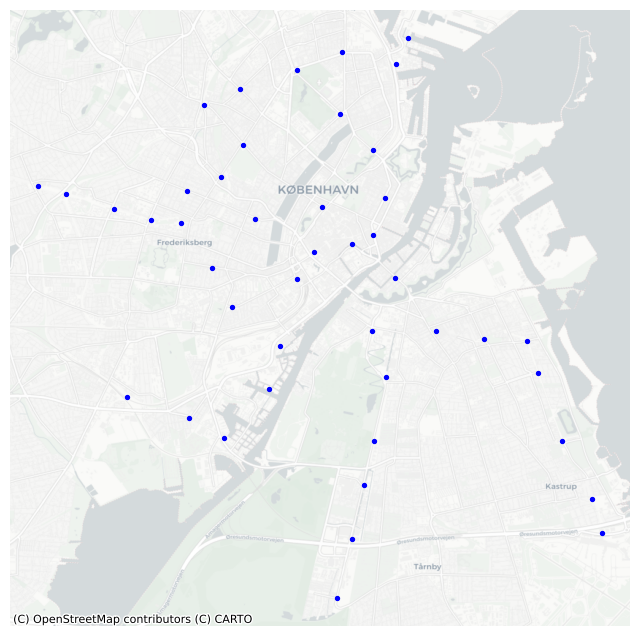

In [61]:
pos = {i: (geom.x, geom.y) for i, geom in zip(gdf_stops_3857.index, gdf_stops_3857.geometry)}

fig, ax = plt.subplots(figsize=(8,8))

nx.draw(G, pos,
        node_size=8,
        edge_color="gray",
        node_color="blue",
        ax=ax,
        with_labels=False)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()

In [62]:
## Find the neighbores of each node so we know which nodes can be connected to which
coords = gdf_stops_3857[['stop_lon','stop_lat']].values
tri = Delaunay(coords)

for simplex in tri.simplices:
    for i in range(3):
        for j in range(i+1,3):
            G.add_edge(simplex[i], simplex[j])


/home/jspe/venvs/Bachelor_project/lib/python3.11/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 29 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


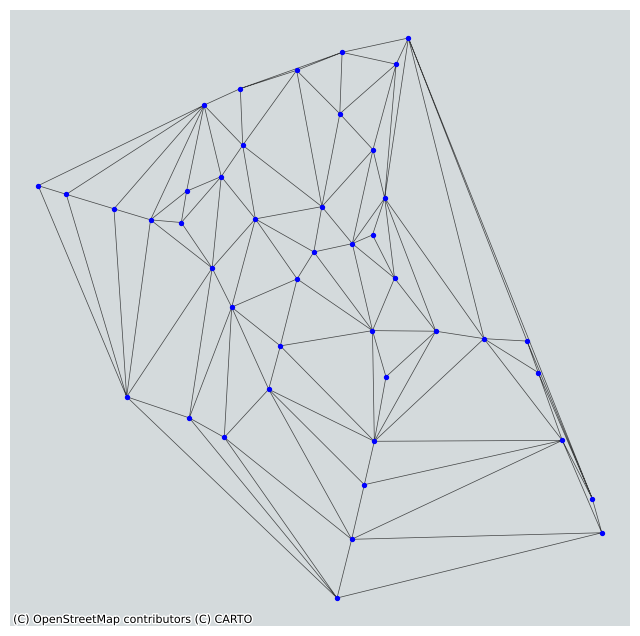

In [63]:
fig, ax = plt.subplots(figsize=(8,8))

# draw triangulation mesh
ax.triplot(
    coords[:,0], coords[:,1],
    tri.simplices,
    color="black",
    linewidth=0.5,
    alpha=0.7
)

ax.scatter(coords[:,0], coords[:,1], s=8, color="blue")

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()


In [67]:
for i in G.nodes:
    G.nodes[i]["stop_id"] = gdf_stops_3857.loc[i, "stop_id"]


In [68]:
list(G.neighbors(1))

#list(G.nodes)[:44]


[np.int32(0),
 np.int32(21),
 np.int32(42),
 np.int32(19),
 np.int32(3),
 np.int32(41)]

In [69]:
G.nodes(data=True)

NodeDataView({0: {'lat': 55.619391, 'lon': 12.575297, 'stop_id': np.int64(8603317)}, 1: {'lat': 55.629055, 'lon': 12.579389, 'stop_id': np.int64(8603315)}, 2: {'lat': 55.645199, 'lon': 12.585728, 'stop_id': np.int64(8603312)}, 3: {'lat': 55.638051, 'lon': 12.582928, 'stop_id': np.int64(8603313)}, 4: {'lat': 55.663422, 'lon': 12.585217, 'stop_id': np.int64(8603310)}, 5: {'lat': 55.655813, 'lon': 12.58899, 'stop_id': np.int64(8603311)}, 6: {'lat': 55.679185, 'lon': 12.585228, 'stop_id': np.int64(8603308)}, 7: {'lat': 55.672054, 'lon': 12.591385, 'stop_id': np.int64(8603309)}, 8: {'lat': 55.681821, 'lon': 12.552431, 'stop_id': np.int64(8603306)}, 9: {'lat': 55.683843, 'lon': 12.571044, 'stop_id': np.int64(8603307)}, 10: {'lat': 55.681669, 'lon': 12.523102, 'stop_id': np.int64(8603304)}, 11: {'lat': 55.681223, 'lon': 12.531719, 'stop_id': np.int64(8603305)}, 12: {'lat': 55.685868, 'lon': 12.499527, 'stop_id': np.int64(8603302)}, 13: {'lat': 55.683482, 'lon': 12.512873, 'stop_id': np.int64(